### Analyzing the Struture of a Single Spectra File

In [27]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [68]:
# Opening file and getting metadata
filename = "apStar-dr17-2M00000002+7417074.fits"

filepath = f'D:\Red_Giant_Classificaition_ML/test/{filename}'

with fits.open(filepath) as file:
    for i, spectra in enumerate(file):
        header = file[1].header
        print(repr(header))
        if spectra.data is not None:
            print(f"Extension {i} has data of shape {spectra.data.shape}\n")
        else:
            print(f"Extension {i} is Header-only\n")



XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 8575                                                  
NAXIS2  =                    5                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
CRVAL1  =                4.179                                                  
CDELT1  =                6E-06                                                  
CRPIX1  =                    1                                                  
CTYPE1  = 'LOG-LINEAR'                                                          
BUNIT   = 'Flux (10^-17 erg/s/cm^2/Ang)'                                        
Extension 0 is Header-only



<>:4: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:4: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\hjmar\AppData\Local\Temp\ipykernel_19132\1723502498.py:4: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  filepath = f'D:\Red_Giant_Classificaition_ML/test/{filename}'


In [69]:
with fits.open(filepath) as file:
    print(file[0].header.get("HISTORY"))

APOGEE Reduction Pipeline Version: 0.17.22
HDU0 : header
HDU1 : flux
HDU2 : flux uncertainty
HDU3 : pixel bitmask
HDU4 : sky
HDU5 : sky uncertainty
HDU6 : telluric
HDU7 : telluric uncertainty
HDU8 : LSF table
HDU9 : RV table
HDU10 : RV table for combined spectrum


From this we gather:
- The data is in log space
- There are 8575 points across five channels
- The five channels are [0] Combined, [1:5] Individual Visits
- The noramlization value is CRVAL1
- The step size between pixels is CDELT1


For our models we will use the flux and error channels.

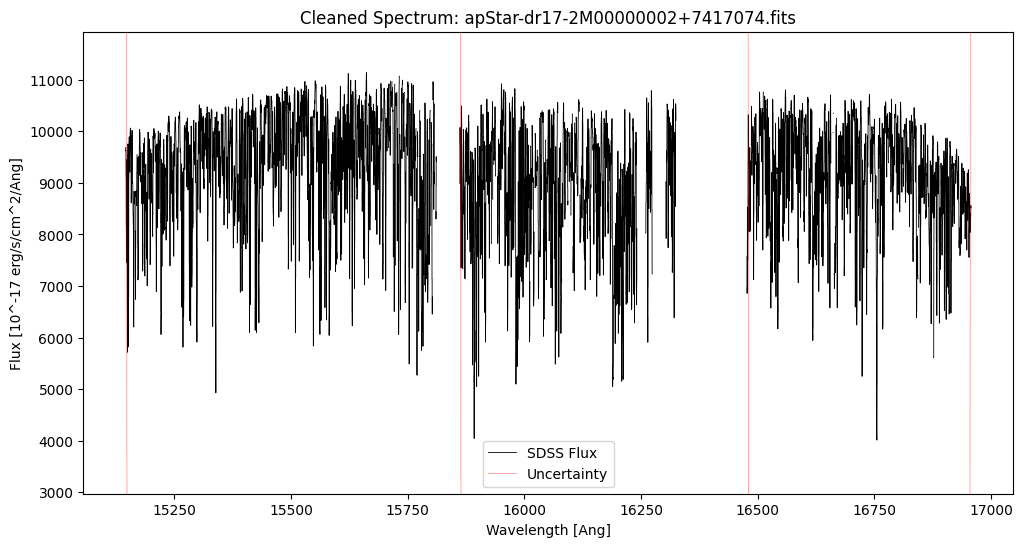

In [73]:
with fits.open(filepath) as file:
    flux = file[1].data[0] 
    error = file[2].data[0]
    mask = file[3].data[0] 
    header = file[1].header

    # Wavelength reconstruction
    n_pixels = len(flux)
    wavelengths = 10**(header['CRVAL1'] + np.arange(n_pixels) * header['CDELT1'])

    # Finding good pixels
    is_good = (mask == 0) & (error > 0) & (flux > 0) & np.isfinite(error)
    plot_flux = np.where(is_good, flux, np.nan)
    plot_error = np.where(is_good, error, np.nan)

    # Dynamic y_limts because of error
    if np.any(is_good):
        y_max = np.nanpercentile(plot_flux, 99) * 1.1
        y_min = np.nanpercentile(plot_flux, 1) * 0.5
    else:
        y_max, y_min = 1, 0 

# Plotting
plt.figure(figsize=(12, 6))
plt.step(wavelengths, plot_flux, where='mid', color='black', lw=0.6, label='SDSS Flux')
plt.step(wavelengths, plot_error, where='mid', color='red', lw=0.6, alpha=0.4, label='Uncertainty')

plt.ylim(y_min, y_max) 
plt.title(f"Cleaned Spectrum: {filename}")
plt.xlabel('Wavelength [Ang]')
plt.ylabel('Flux [10^-17 erg/s/cm^2/Ang]')
plt.legend()
plt.show()

The gaps in the data here are from the three different measurements of this star. The error skyrockets there because there's no data.